In [1]:
# BE 530 Final Project 
# Author Jane Kozz
# Part 1 Classical ML for Retinal OCT Classification
#============================================


import os
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
from PIL import Image

# ------------------------------
#  Load dataset 

DATASET_ROOT = r"C:\Users\kozzj\Documents\UofL\Medical dataset Retinal OCT images\OCT_small"
#MAX_IMAGES_PER_CLASS = None
# ----------------------------
# Find dataset split 

dataset_root = Path(DATASET_ROOT)

train_dir = dataset_root / "train"
val_dir = dataset_root / "val"
test_dir = dataset_root / "test"

# some datasets use "valid" instead of "val"
if not val_dir.exists():
   val_dir = dataset_root / "val"

   if not train_dir.exists() or not val_dir.exists() or not test_dir.exists():
      raise FileNotFoundError(
"Could not find train / val / test folders. "
"Please check DATASET_ROOT."
)

print("Using dataset folders:")
print("Train:", train_dir)
print("Val: ", val_dir)
print("Test: ", test_dir)


Using dataset folders:
Train: C:\Users\kozzj\Documents\UofL\Medical dataset Retinal OCT images\OCT_small\train
Val:  C:\Users\kozzj\Documents\UofL\Medical dataset Retinal OCT images\OCT_small\val
Test:  C:\Users\kozzj\Documents\UofL\Medical dataset Retinal OCT images\OCT_small\test


In [2]:
# Collect image paths 

def collect_image_paths(split_dir, max_per_class=None):
   image_paths = []
   labels = []

   class_dirs = [d for d in split_dir.iterdir() if d.is_dir()]
   class_dirs = sorted(class_dirs, key=lambda x: x.name)

   for class_dir in class_dirs:
       class_name = class_dir.name

       files = []
       for ext in ("*.jpeg", "*.jpg", "*.png", "*.bmp"):
           files.extend(class_dir.glob(ext))
       files = sorted(files)

       if max_per_class is not None:
          files = files[:max_per_class]

       for f in files:
          image_paths.append(f)
          labels.append(class_name)

   return image_paths, labels
    
MAX_IMAGES_PER_CLASS = 300

train_paths, train_labels = collect_image_paths(train_dir, MAX_IMAGES_PER_CLASS)
val_paths, val_labels = collect_image_paths(val_dir, MAX_IMAGES_PER_CLASS)
test_paths, test_labels = collect_image_paths(test_dir, MAX_IMAGES_PER_CLASS)




In [3]:
print("Train:", len(train_paths))
print("Val:  ", len(val_paths))
print("Test: ", len(test_paths))

from collections import Counter

print("Train:", Counter(train_labels))
print("Val:  ", Counter(val_labels))
print("Test: ", Counter(test_labels))



Train: 1200
Val:   32
Test:  968
Train: Counter({'CNV': 300, 'DME': 300, 'DRUSEN': 300, 'NORMAL': 300})
Val:   Counter({'CNV': 8, 'DME': 8, 'DRUSEN': 8, 'NORMAL': 8})
Test:  Counter({'CNV': 242, 'DME': 242, 'DRUSEN': 242, 'NORMAL': 242})


In [4]:
import numpy as np
from PIL import Image

IMG_SIZE = (128, 128)
USE_GRAYSCALE = True

def load_and_preprocess_images(paths, img_size=(128, 128), grayscale=True):
   features = []

   for path in paths:
      img = Image.open(path)

      if grayscale:
         img = img.convert("L")

      img = img.resize(img_size)
      arr = np.array(img, dtype=np.float32)

   # normalize pixel values to [0,1]
      arr = arr / 255.0

   # flatten image to 1D feature vector
      features.append(arr.flatten())

   return np.array(features, dtype=np.float32)

X_train_raw = load_and_preprocess_images(train_paths, IMG_SIZE, USE_GRAYSCALE)
X_val_raw = load_and_preprocess_images(val_paths, IMG_SIZE, USE_GRAYSCALE)
X_test_raw = load_and_preprocess_images(test_paths, IMG_SIZE, USE_GRAYSCALE)

print("X_train_raw shape:", X_train_raw.shape)
print("X_val_raw shape: ", X_val_raw.shape)
print("X_test_raw shape: ", X_test_raw.shape)

X_train_raw shape: (1200, 16384)
X_val_raw shape:  (32, 16384)
X_test_raw shape:  (968, 16384)


Classes: [np.str_('CNV'), np.str_('DME'), np.str_('DRUSEN'), np.str_('NORMAL')]
Scaled train shape: (1200, 16384)
Scaled val shape:  (32, 16384)
Scaled test shape:  (968, 16384)
PCA train shape: (1200, 100)
PCA val shape:  (32, 100)
PCA test shape:  (968, 100)


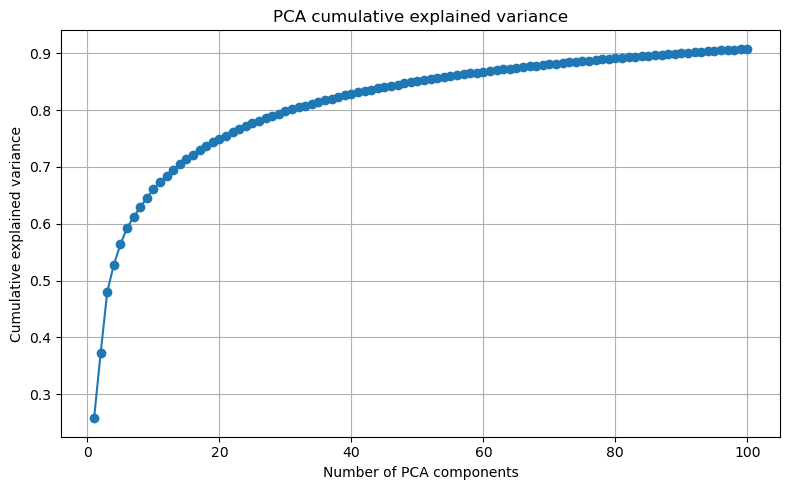

Explained variance by 100 components: 0.90768874


In [5]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt


# Encode labels

label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(train_labels)
y_val = label_encoder.transform(val_labels)
y_test = label_encoder.transform(test_labels)

class_names = list(label_encoder.classes_)
print("Classes:", class_names)

# Scale features
# IMPORTANT: fit only on training data

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled = scaler.transform(X_val_raw)
X_test_scaled = scaler.transform(X_test_raw)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled val shape: ", X_val_scaled.shape)
print("Scaled test shape: ", X_test_scaled.shape)

#  PCA
# IMPORTANT: fit only on training data

N_COMPONENTS = 100

pca = PCA(n_components=N_COMPONENTS, random_state=42)

X_train = pca.fit_transform(X_train_scaled)
X_val = pca.transform(X_val_scaled)
X_test = pca.transform(X_test_scaled)

print("PCA train shape:", X_train.shape)
print("PCA val shape: ", X_val.shape)
print("PCA test shape: ", X_test.shape)


#  Plot cumulative explained variance

cumulative_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_var)+1), cumulative_var, marker='o')
plt.xlabel("Number of PCA components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA cumulative explained variance")
plt.grid(True)
plt.tight_layout()
plt.show()

print("Explained variance by 100 components:", cumulative_var[-1])

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Logistic Regression

log_reg = LogisticRegression(max_iter=2000)

log_reg.fit(X_train, y_train)

val_pred_lr = log_reg.predict(X_val)
test_pred_lr = log_reg.predict(X_test)

lr_val_acc = accuracy_score(y_val, val_pred_lr)
lr_test_acc = accuracy_score(y_test, test_pred_lr)

print("Logistic Regression")
print("Validation accuracy:", lr_val_acc)
print("Test accuracy:", lr_test_acc)

# SVM

svm = SVC(kernel='rbf')

svm.fit(X_train, y_train)

val_pred_svm = svm.predict(X_val)
test_pred_svm = svm.predict(X_test)

svm_val_acc = accuracy_score(y_val, val_pred_svm)
svm_test_acc = accuracy_score(y_test, test_pred_svm)

print("\nSVM")
print("Validation accuracy:", svm_val_acc)
print("Test accuracy:", svm_test_acc)

# Random Forest

rf = RandomForestClassifier(n_estimators=200, random_state=42)

rf.fit(X_train, y_train)

val_pred_rf = rf.predict(X_val)
test_pred_rf = rf.predict(X_test)

rf_val_acc = accuracy_score(y_val, val_pred_rf)
rf_test_acc = accuracy_score(y_test, test_pred_rf)

print("\nRandom Forest")
print("Validation accuracy:", rf_val_acc)
print("Test accuracy:", rf_test_acc)


Logistic Regression
Validation accuracy: 0.25
Test accuracy: 0.35640495867768596

SVM
Validation accuracy: 0.3125
Test accuracy: 0.4132231404958678

Random Forest
Validation accuracy: 0.40625
Test accuracy: 0.36673553719008267


<Figure size 600x600 with 0 Axes>

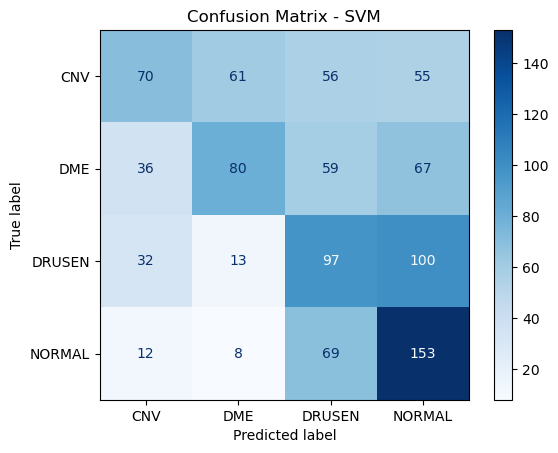

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#  best model (SVM)
best_model = svm

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
display_labels=class_names)

plt.figure(figsize=(6,6))
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - SVM")
plt.show()


In [8]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

val_pred_base = baseline.predict(X_val)
test_pred_base = baseline.predict(X_test)

base_val_acc = accuracy_score(y_val, val_pred_base)
base_test_acc = accuracy_score(y_test, test_pred_base)

print("Baseline (Most Frequent)")
print("Validation accuracy:", base_val_acc)
print("Test accuracy:", base_test_acc)


Baseline (Most Frequent)
Validation accuracy: 0.25
Test accuracy: 0.25


In [9]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

         CNV       0.47      0.29      0.36       242
         DME       0.49      0.33      0.40       242
      DRUSEN       0.35      0.40      0.37       242
      NORMAL       0.41      0.63      0.50       242

    accuracy                           0.41       968
   macro avg       0.43      0.41      0.41       968
weighted avg       0.43      0.41      0.41       968



In [10]:
#Part 2 Deep Learning for Retinal OCT images 

import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import image_dataset_from_directory


DATASET_ROOT = r"C:\Users\kozzj\Documents\UofL\Medical dataset Retinal OCT images\OCT_small"

IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32
SEED = 42

In [11]:
#Load train, validation, and test datasets

train_dir = os.path.join(DATASET_ROOT, "train")
val_dir = os.path.join(DATASET_ROOT, "val")
test_dir = os.path.join(DATASET_ROOT, "test")

train_ds = image_dataset_from_directory(
train_dir,
image_size=(IMG_HEIGHT, IMG_WIDTH),
batch_size=BATCH_SIZE,
color_mode="grayscale",
shuffle=True,
seed=SEED
)

val_ds = image_dataset_from_directory(
val_dir,
image_size=(IMG_HEIGHT, IMG_WIDTH),
batch_size=BATCH_SIZE,
color_mode="grayscale",
shuffle=False
)

test_ds = image_dataset_from_directory(
test_dir,
image_size=(IMG_HEIGHT, IMG_WIDTH),
batch_size=BATCH_SIZE,
color_mode="grayscale",
shuffle=False
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 4000 files belonging to 4 classes.
Found 32 files belonging to 4 classes.
Found 968 files belonging to 4 classes.
Classes: ['CNV', 'DME', 'DRUSEN', 'NORMAL']


In [12]:
#Improve performance

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [13]:
#Build CNN model

model = models.Sequential([
layers.Rescaling(1./255, input_shape=(IMG_HEIGHT, IMG_WIDTH, 1)),

layers.Conv2D(32, (3,3), activation='relu'),
layers.MaxPooling2D(),

layers.Conv2D(64, (3,3), activation='relu'),
layers.MaxPooling2D(),

layers.Conv2D(128, (3,3), activation='relu'),
layers.MaxPooling2D(),

layers.Flatten(),
layers.Dense(128, activation='relu'),
layers.Dropout(0.3),
layers.Dense(4, activation='softmax')
])

model.summary()


C:\Users\kozzj\anaconda3\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,580 (12.61 MB)

 Trainable params: 3,304,580 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
#Complete model

model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)

In [15]:
#Train model 

history = model.fit(
train_ds,
validation_data=val_ds,
epochs=10
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 148ms/step - accuracy: 0.4465 - loss: 1.1892 - val_accuracy: 0.5938 - val_loss: 0.8784
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 152ms/step - accuracy: 0.6765 - loss: 0.7958 - val_accuracy: 0.8750 - val_loss: 0.5139
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 155ms/step - accuracy: 0.7797 - loss: 0.5817 - val_accuracy: 0.8750 - val_loss: 0.4507
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 159ms/step - accuracy: 0.8313 - loss: 0.4501 - val_accuracy: 0.9062 - val_loss: 0.2939
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 162ms/step - accuracy: 0.8752 - loss: 0.3464 - val_accuracy: 0.8438 - val_loss: 0.4441
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 160ms/step - accuracy: 0.9158 - loss: 0.2481 - val_accuracy: 0.8750 - val_loss: 0.4158
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 159ms/step - accuracy: 0.9308 - loss: 0.1955 - val_accuracy: 0.8750 - val_loss: 0.2768
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 157ms/step - accuracy: 0.9317 - loss: 0

In [16]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test accuracy:", test_acc)

31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.7831 - loss: 0.8411
Test accuracy: 0.7830578684806824


In [17]:
import numpy as np
from sklearn.metrics import classification_report

y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred = np.argmax(model.predict(test_ds), axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))

31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step
              precision    recall  f1-score   support

         CNV       0.82      0.82      0.82       242
         DME       0.70      0.79      0.74       242
      DRUSEN       0.78      0.61      0.68       242
      NORMAL       0.84      0.91      0.87       242

    accuracy                           0.78       968
   macro avg       0.78      0.78      0.78       968
weighted avg       0.78      0.78      0.78       968



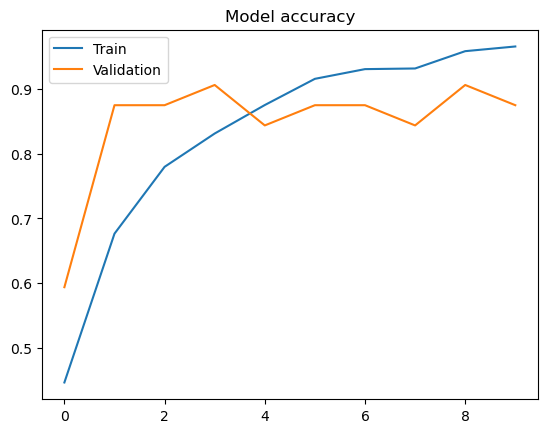

In [18]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.title('Model accuracy')
plt.show()

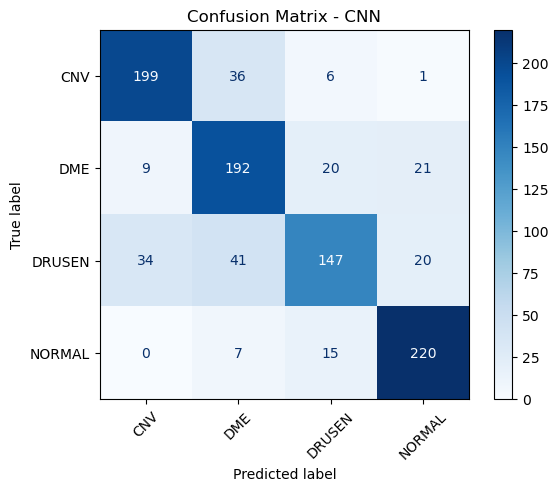

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45)

plt.title ("Confusion Matrix - CNN")
plt.show()